# ANÁLISE TRABALHO

In [1]:
import time
from datetime import datetime
import random
from structures   import Order, Stack
from order_book import BuyList
from queue_ordens import Queue
import matplotlib.pyplot as plt

### COMMIT 1 E 2 - FUNÇÕES AUXILIARES DE MEDIÇÃO

In [2]:
def gera_ordens(n: int):
    """Gera uma lista com N objetos Order com dados aleatórios."""
    ordens = []
    for i in range(1, n + 1):
        tipo = random.choice(['C', 'V'])
        preco = round(random.uniform(10.0, 200.0), 2)
        qtd   = random.randint(1, 500)
        ordens.append(Order(i, tipo, preco, qtd, datetime.now()))
    return ordens


def mede_tempo_insercao_lista(n: int, repeticoes: int = 10):
    """
    Mede o tempo médio de inserção ordenada de N ordens na BuyList.
    Executa o experimento várias vezes e retorna a média.
    """
    tempos = []
    for _ in range(repeticoes):
        lista = BuyList()
        ordens = gera_ordens(n)
        inicio = time.perf_counter()
        for o in ordens:
            lista.insere_ordenado(o)
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return sum(tempos) / repeticoes

def mede_tempo_fila(n: int, repeticoes: int = 10):
    """
    Mede o tempo médio de N operações enqueue + dequeue.
    """
    tempos = []
    for _ in range(repeticoes):
        fila = Queue()
        ordens = gera_ordens(n)
        inicio = time.perf_counter()
        for o in ordens:
            fila.enqueue(o)
        for _ in range(n):
            fila.dequeue()
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return sum(tempos) / repeticoes


def mede_tempo_pilha(n: int, repeticoes: int = 10):
    """
    Mede o tempo médio de N operações push + pop.
    """
    tempos = []
    for _ in range(repeticoes):
        pilha = Stack()
        inicio = time.perf_counter()
        for i in range(n):
            pilha.push(i)
        for _ in range(n):
            pilha.pop()
        fim = time.perf_counter()
        tempos.append(fim - inicio)
    return sum(tempos) / repeticoes

Commit 3 - Adicionando gráficos de tempo por volume de ordens.


Medindo tempos...
  n=   100 | Lista ordenada: 0.000192s | Fila: 0.000043s | Pilha: 0.000034s
  n=   500 | Lista ordenada: 0.004264s | Fila: 0.000252s | Pilha: 0.000187s
  n=  1000 | Lista ordenada: 0.019037s | Fila: 0.000557s | Pilha: 0.000588s
  n=  2000 | Lista ordenada: 0.072164s | Fila: 0.000791s | Pilha: 0.000713s
  n=  3000 | Lista ordenada: 0.152972s | Fila: 0.001413s | Pilha: 0.001648s
  n=  5000 | Lista ordenada: 0.409523s | Fila: 0.002075s | Pilha: 0.002316s
  n=  7500 | Lista ordenada: 0.920101s | Fila: 0.003811s | Pilha: 0.003209s
  n= 10000 | Lista ordenada: 1.855779s | Fila: 0.004666s | Pilha: 0.005997s
Medição concluída!



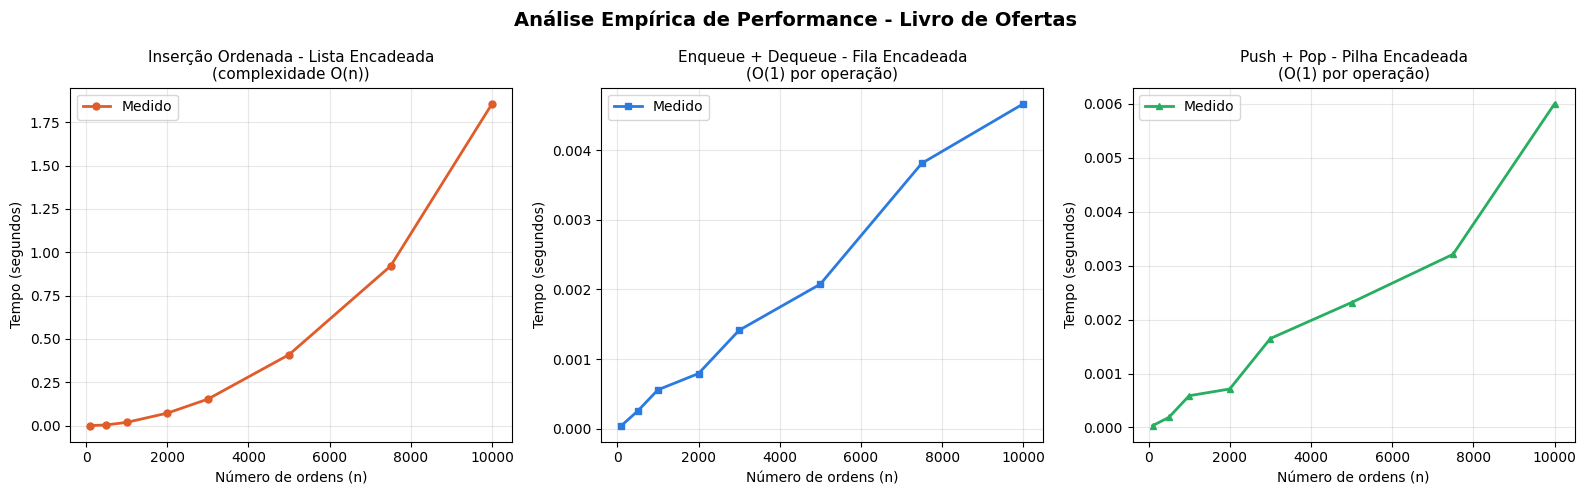

Gráfico salvo como 'grafico_performance.png'


In [3]:
# Rodamos cada função para volumes crescentes e coletamos os tempos, depois geramos os gráficos.

# volumes de teste
VOLUMES = [100, 500, 1000, 2000, 3000, 5000, 7500, 10000]

print("Medindo tempos...")

tempos_lista = []
tempos_fila = []
tempos_pilha = []

for n in VOLUMES:
    t_lista = mede_tempo_insercao_lista(n)
    t_fila = mede_tempo_fila(n)
    t_pilha = mede_tempo_pilha(n)

    tempos_lista.append(t_lista)
    tempos_fila.append(t_fila)
    tempos_pilha.append(t_pilha)

    print(f"  n={n:>6} | Lista ordenada: {t_lista:.6f}s | "
          f"Fila: {t_fila:.6f}s | Pilha: {t_pilha:.6f}s")

print("Medição concluída!\n")


# ---- Gráfico 1: Inserção ordenada na lista (O(n)) ----

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Análise Empírica de Performance - Livro de Ofertas",
             fontsize=14, fontweight='bold')

axes[0].plot(VOLUMES, tempos_lista, marker='o', color='#e05c2a',
             linewidth=2, markersize=5, label='Medido')
axes[0].set_title("Inserção Ordenada - Lista Encadeada\n(complexidade O(n))",
                  fontsize=11)
axes[0].set_xlabel("Número de ordens (n)")
axes[0].set_ylabel("Tempo (segundos)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ---- Gráfico 2: Fila — O(1) por operação ----

axes[1].plot(VOLUMES, tempos_fila, marker='s', color='#2a7ae0',
             linewidth=2, markersize=5, label='Medido')
axes[1].set_title("Enqueue + Dequeue - Fila Encadeada\n(O(1) por operação)",
                  fontsize=11)
axes[1].set_xlabel("Número de ordens (n)")
axes[1].set_ylabel("Tempo (segundos)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# ---- Gráfico 3: Pilha — O(1) por operação ----

axes[2].plot(VOLUMES, tempos_pilha, marker='^', color='#27ae60',
             linewidth=2, markersize=5, label='Medido')
axes[2].set_title("Push + Pop - Pilha Encadeada\n(O(1) por operação)",
                  fontsize=11)
axes[2].set_xlabel("Número de ordens (n)")
axes[2].set_ylabel("Tempo (segundos)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig("plotagens/grafico_performance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'grafico_performance.png'")

## Análise Teórica de Complexidade

### 1. Fila de Entrada (Queue)
| Operação   | Complexidade | Justificativa |
|------------|--------------|----------------|
| enqueue()  | O(1)         | Ponteiro direto para o fim |
| dequeue()  | O(1)         | Ponteiro direto para o início |
| esta_vazia | O(1)         | Apenas checa atributo |

### 2. Pilha de Undo (Stack)
| Operação   | Complexidade | Justificativa |
|------------|--------------|----------------|
| push()     | O(1)         | Insere logo após o sentinela |
| pop()      | O(1)         | Remove o primeiro nó após sentinela |

### 3. Livro de Ofertas — Listas Ordenadas
| Operação            | Complexidade | Justificativa |
|---------------------|--------------|----------------|
| insere_ordenado()   | O(n)         | Percorre até achar a posição correta |
| remove_por_id()     | O(n)         | Percorre até achar o ID |
| melhor_oferta()     | O(1)         | Acesso direto ao início |

**Nota:** O custo total de N inserções na lista é O(n²),
enquanto N operações de fila/pilha custam O(n).
Isso explica a diferença visual nos gráficos.

# Commit 5, relatório final. 

In [4]:
print("\n" + "=" * 60)
print("ANÁLISE EMPÍRICA — RESUMO")
print("=" * 60)

print("\n[1] Inserção ordenada na lista (O(n) por inserção):")
razao = tempos_lista[-1] / tempos_lista[0] if tempos_lista[0] > 0 else 0
fator = VOLUMES[-1]     / VOLUMES[0]
print(f"    Crescimento de n: {fator:.0f}x   |   "
      f"Crescimento do tempo: {razao:.1f}x")
print(f"    Conclusão: crescimento super-linear (~O(n²) no total),")
print(f"    confirmando O(n) por inserção individual.")

print("\n[2] Fila encadeada (O(1) por operação):")
razao_f = tempos_fila[-1] / tempos_fila[0] if tempos_fila[0] > 0 else 0
print(f"    Crescimento de n: {fator:.0f}x   |   "
      f"Crescimento do tempo: {razao_f:.1f}x")
print(f"    Conclusão: crescimento linear, confirmando O(1) por operação.")

print("\n[3] Pilha encadeada (O(1) por operação):")
razao_p = tempos_pilha[-1] / tempos_pilha[0] if tempos_pilha[0] > 0 else 0
print(f"    Crescimento de n: {fator:.0f}x   |   "
      f"Crescimento do tempo: {razao_p:.1f}x")
print(f"    Conclusão: crescimento linear, confirmando O(1) por operação.")

print("\n[4] Comparação com estruturas futuras (árvores):")
print("    A inserção ordenada em lista encadeada é O(n) porque")
print("    percorre sequencialmente até achar a posição certa.")
print("    Uma Árvore Binária de Busca (ABB) reduziria isso para")
print("    O(log n) no caso médio — muito mais eficiente para")
print("    grandes volumes, como veremos na próxima etapa da disciplina.")

print("\n" + "=" * 60)


ANÁLISE EMPÍRICA — RESUMO

[1] Inserção ordenada na lista (O(n) por inserção):
    Crescimento de n: 100x   |   Crescimento do tempo: 9678.6x
    Conclusão: crescimento super-linear (~O(n²) no total),
    confirmando O(n) por inserção individual.

[2] Fila encadeada (O(1) por operação):
    Crescimento de n: 100x   |   Crescimento do tempo: 108.9x
    Conclusão: crescimento linear, confirmando O(1) por operação.

[3] Pilha encadeada (O(1) por operação):
    Crescimento de n: 100x   |   Crescimento do tempo: 176.4x
    Conclusão: crescimento linear, confirmando O(1) por operação.

[4] Comparação com estruturas futuras (árvores):
    A inserção ordenada em lista encadeada é O(n) porque
    percorre sequencialmente até achar a posição certa.
    Uma Árvore Binária de Busca (ABB) reduziria isso para
    O(log n) no caso médio — muito mais eficiente para
    grandes volumes, como veremos na próxima etapa da disciplina.



# COMMIT 6 - Gráfico Comparativo

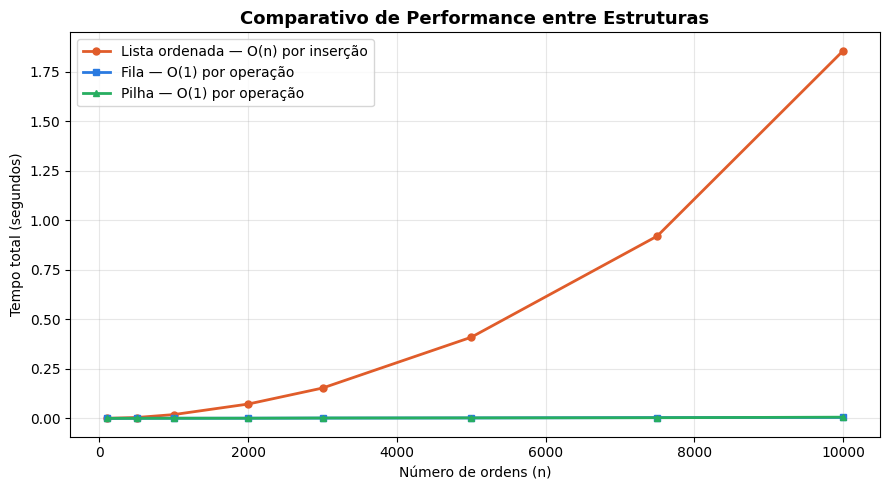

Gráfico comparativo salvo como 'plotagens/grafico_comparativo.png'


In [5]:
fig2, ax = plt.subplots(figsize=(9, 5))

ax.plot(VOLUMES, tempos_lista, marker='o', color='#e05c2a',
        linewidth=2, markersize=5, label='Lista ordenada — O(n) por inserção')
ax.plot(VOLUMES, tempos_fila, marker='s', color='#2a7ae0',
        linewidth=2, markersize=5, label='Fila — O(1) por operação')
ax.plot(VOLUMES, tempos_pilha, marker='^', color='#27ae60',
        linewidth=2, markersize=5, label='Pilha — O(1) por operação')

ax.set_title("Comparativo de Performance entre Estruturas", fontsize=13,
             fontweight='bold')
ax.set_xlabel("Número de ordens (n)")
ax.set_ylabel("Tempo total (segundos)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plotagens/grafico_comparativo.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico comparativo salvo como 'plotagens/grafico_comparativo.png'")